# Heart Disease Prediction

The goal is to classify whether a patient has heart disease from clinical measurements (age, chest pain type, resting blood pressure, cholesterol, maximum heart rate and others). The dataset has 303 patients (Cleveland heart disease data, `heart.csv`).

Reference solutions (same author, same data): [Heart Disease Prediction using Machine Learning](https://amanxai.com/2020/11/10/heart-disease-prediction-using-machine-learning/) (Logistic Regression, 70/30 split) and [Heart Disease Prediction with Machine Learning](https://amanxai.com/2020/05/20/heart-disease-prediction-with-machine-learning/) (KNN and Random Forest, 10-fold cross-validation). Dataset: [heart.csv](https://amanxai.com/wp-content/uploads/2020/05/heart.csv).

Both references report accuracy only, on a 91-row test set or on a cross-validation whose scaler was fitted on all the data. They also read the target the wrong way round (see the target check below).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Classification/heart_disease_prediction')

## Data Loading

In [2]:
df = pd.read_csv("heart.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Data Cleaning

The references state that the data is perfect because it has no null values. Two other problems are visible:

- `ca` (number of major vessels, valid range 0 to 3) has the value 4 in 5 rows, and `thal` (valid values 1 to 3) has the value 0 in 2 rows. These are missing values encoded as numbers. With only 7 rows affected, they are dropped.
- One row is an exact duplicate.

In [3]:
print("duplicated rows:", df.duplicated().sum())
print("invalid ca (4):", (df["ca"] == 4).sum(), "| invalid thal (0):", (df["thal"] == 0).sum())

df = df.drop_duplicates()
df = df[(df["ca"] < 4) & (df["thal"] > 0)].reset_index(drop=True)
df.shape

duplicated rows: 1
invalid ca (4): 5 | invalid thal (0): 2


(296, 14)

## Target Check

The data description says `target = 1` means heart disease, and the reference reads it that way. But its own interpretation is medically backwards: it says patients with `ca = 0` (no blocked vessels) are more likely to have heart disease. Comparing the two groups shows why.

In [4]:
df.groupby("target")[["age", "thalach", "oldpeak", "exang", "ca", "sex"]].mean().round(2)

,age,thalach,oldpeak,exang,ca,sex
target,,,,,,
0,56.74,138.95,1.6,0.54,1.15,0.82
1,52.64,158.58,0.6,0.14,0.28,0.56


The group with `target = 0` is older, has a lower maximum heart rate (`thalach`), a higher ST depression (`oldpeak`), more exercise-induced angina (`exang`) and more blocked vessels (`ca`). Those are all signs of heart disease, so in this version of the dataset `target = 0` is the patient group and `target = 1` is the healthy group. The label is flipped into a new column `disease` (1 = heart disease) so that precision and recall of the positive class mean what they should. The model scores do not change, but the interpretation does: the recall that matters is the share of sick patients that are found.

In [5]:
df["disease"] = 1 - df["target"]
df = df.drop(columns="target")
df["disease"].value_counts()

disease
0    160
1    136
Name: count, dtype: int64

## Exploratory Data Analysis

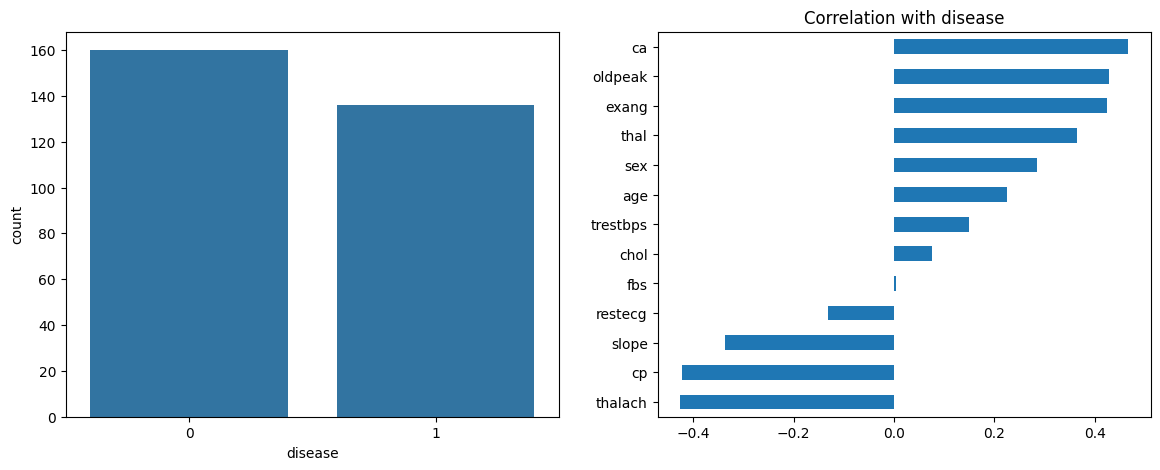

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x="disease", data=df, ax=axes[0])
df.corr()["disease"].drop("disease").sort_values().plot(kind="barh", ax=axes[1], title="Correlation with disease")
plt.show()

The classes are nearly balanced (about 46% sick), so accuracy is a usable metric here, but recall of the sick class is still the one to watch: a missed patient is worse than a false alarm. Chest pain type (`cp`), maximum heart rate (`thalach`), exercise angina (`exang`), ST depression (`oldpeak`) and vessel count (`ca`) have the strongest correlations. `fbs` and `chol` are almost uncorrelated with the disease.

## Feature Engineering

The categorical columns (`cp`, `restecg`, `slope`, `ca`, `thal`) are one-hot encoded with `get_dummies(drop_first=True)`. The split is 80/20 and stratified. The `MinMaxScaler` is fitted on the training set only and then applied to the test set, so that no test information leaks into the scaling.

In [7]:
x = pd.get_dummies(df.drop(columns="disease"), columns=["cp", "restecg", "slope", "ca", "thal"], drop_first=True)
y = df["disease"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler().fit(x_train)
x_train_s, x_test_s = scaler.transform(x_train), scaler.transform(x_test)
x_train.shape, x_test.shape

((236, 20), (60, 20))

## Model Training

Six classifiers are trained and evaluated on the test set. Precision, recall and F1 are those of the sick class.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=12),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

def evaluate(model):
    pred = model.fit(x_train_s, y_train).predict(x_test_s)
    report = classification_report(y_test, pred, output_dict=True)["1"]
    return {"Accuracy": accuracy_score(y_test, pred), "Precision": report["precision"], "Recall": report["recall"], "F1": report["f1-score"]}

pd.DataFrame({name: evaluate(model) for name, model in models.items()}).T.round(3)

,Accuracy,Precision,Recall,F1
Logistic Regression,0.883,0.889,0.857,0.873
KNN,0.833,0.875,0.750,0.808
Naive Bayes,0.850,0.880,0.786,0.830
Decision Tree,0.733,0.700,0.750,0.724
Random Forest,0.883,0.889,0.857,0.873
Gradient Boosting,0.867,0.885,0.821,0.852


## Evaluation

The test set has only 60 patients, so one patient changes the accuracy by 1.7 points and the ranking of the models is not reliable. A 10-fold cross-validation uses all patients for testing. The scaler is placed inside a pipeline so that it is refitted on the training part of each fold. `cross_validate` and `make_pipeline` were found while researching leakage-free validation and are not covered in class.

In [9]:
cv = {name: cross_validate(make_pipeline(MinMaxScaler(), model), x, y, cv=10, scoring=["accuracy", "recall", "f1"])
      for name, model in models.items()}

pd.DataFrame({name: {m: f"{r[f'test_{m}'].mean():.3f} +/- {r[f'test_{m}'].std():.3f}" for m in ["accuracy", "recall", "f1"]}
              for name, r in cv.items()}).T

,accuracy,recall,f1
Logistic Regression,0.834 +/- 0.050,0.807 +/- 0.104,0.815 +/- 0.060
KNN,0.821 +/- 0.073,0.755 +/- 0.124,0.792 +/- 0.089
Naive Bayes,0.841 +/- 0.078,0.777 +/- 0.147,0.811 +/- 0.115
Decision Tree,0.696 +/- 0.070,0.667 +/- 0.096,0.668 +/- 0.076
Random Forest,0.814 +/- 0.065,0.777 +/- 0.113,0.791 +/- 0.075
Gradient Boosting,0.790 +/- 0.076,0.732 +/- 0.102,0.762 +/- 0.080


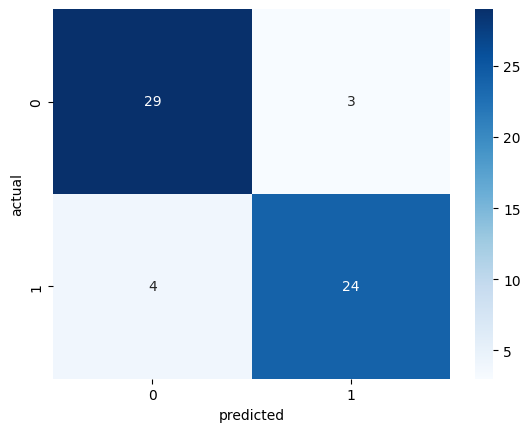

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        32
           1       0.89      0.86      0.87        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [10]:
best = models["Logistic Regression"].fit(x_train_s, y_train)
pred = best.predict(x_test_s)

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("actual"); plt.show()
print(classification_report(y_test, pred))

The reference results are reproduced below. The first is the Logistic Regression of the November article (70/30 split), read with the corrected label. The second is the KNN (k=12) of the May article, whose scaler was fitted on all the data before the cross-validation, compared with the leakage-free version.

In [11]:
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.3, random_state=42)
ref_scaler = MinMaxScaler().fit(x_tr)
ref_lr = LogisticRegression().fit(ref_scaler.transform(x_tr), y_tr)
print("reference-style split (70/30):")
print(classification_report(y_te, ref_lr.predict(ref_scaler.transform(x_te))))

knn = KNeighborsClassifier(n_neighbors=12)
leaky = cross_validate(knn, MinMaxScaler().fit_transform(x), y, cv=10)["test_score"].mean()
clean = cross_validate(make_pipeline(MinMaxScaler(), knn), x, y, cv=10)["test_score"].mean()
print("KNN k=12, scaler fitted on all data:", round(leaky, 3), "| scaler inside the folds:", round(clean, 3))

reference-style split (70/30):
              precision    recall  f1-score   support

           0       0.92      0.87      0.90        54
           1       0.82      0.89      0.85        35

    accuracy                           0.88        89
   macro avg       0.87      0.88      0.87        89
weighted avg       0.88      0.88      0.88        89

KNN k=12, scaler fitted on all data: 0.824 | scaler inside the folds: 0.821


## Conclusion

**Data.** The references treat the data as clean. It has one duplicate row and 7 rows with impossible codes (`ca = 4`, `thal = 0`), which were dropped (296 patients left). More importantly, the label is flipped in this version of the dataset: the group with `target = 0` is older, has a lower maximum heart rate and more exercise angina and blocked vessels, so it is the sick group. The reference reads `target = 1` as disease, which leads to medically wrong statements (for example that `ca = 0` raises the risk). We recoded it to a `disease` column.

**Models.** On a stratified 80/20 split (60 test patients), Logistic Regression and Random Forest reach an accuracy of 0.883 and a sick-class recall of 0.857. A 10-fold cross-validation with the scaler inside each fold gives a more reliable picture:

| Model | Accuracy | Recall (sick) | F1 |
|---|---|---|---|
| Logistic Regression | 0.834 +/- 0.050 | 0.807 +/- 0.104 | 0.815 +/- 0.060 |
| Naive Bayes | 0.841 +/- 0.078 | 0.777 +/- 0.147 | 0.811 +/- 0.115 |
| KNN (k=12) | 0.821 +/- 0.073 | 0.755 +/- 0.124 | 0.792 +/- 0.089 |
| Random Forest | 0.814 +/- 0.065 | 0.777 +/- 0.113 | 0.791 +/- 0.075 |
| Gradient Boosting | 0.790 +/- 0.076 | 0.732 +/- 0.102 | 0.762 +/- 0.080 |
| Decision Tree | 0.696 +/- 0.070 | 0.667 +/- 0.096 | 0.668 +/- 0.076 |

The differences between the first four models are smaller than the fold-to-fold standard deviation, so no single model can be called best. Only the Decision Tree is clearly worse. The single split put Random Forest (0.883) and Gradient Boosting (0.867) at or near the top, while in cross-validation they fall behind Logistic Regression and Naive Bayes, which shows how noisy a 60-patient test set is.

**Reference comparison.** With the reference's 70/30 split, Logistic Regression gives an accuracy of 0.88, close to the 0.868 of the article. The reference reports the recall of "class 1" (0.90), which is the healthy group under the correct reading; the recall for sick patients in its report is 0.83. For the KNN of the May article, fitting the scaler on all the data before cross-validation changes the accuracy by only 0.003 here (0.824 versus 0.821), so the leak is real but negligible on this dataset. Our KNN score is below the 0.845 of the article, which we attribute to the removed duplicate and invalid rows and a different encoding, not to the leak.

**Limitations.** With 296 patients, every estimate has a wide uncertainty (a recall standard deviation of 0.10 or more across folds). A recall of about 0.8 means roughly one sick patient in five is missed, which would need a lower decision threshold in a real screening setting. We did not tune hyperparameters, to avoid overfitting to such a small dataset.